# Distributed Overvoltage Hosting Capacity (Fixed Locations, Monte Carlo)

This notebook illustrates **distributed hosting capacity** with **random bus selection** (Monte Carlo). For each number of buses (1 to 7), we run many scenarios where the bus locations are randomly chosen. Power is split equally among the generators. Boxplots show the distribution of hosting capacity across scenarios.

In [1]:
#!pip install py-dss-interface
#!pip install py-dss-toolkit
#!pip install seaborn
#!git clone https://github.com/PauloRadatz/opendss-python-examples.git
#%cd opendss-python-examples

In [2]:
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import py_dss_interface
from py_dss_toolkit import dss_tools

random.seed(0)  # Reproducible results

# --- Helper functions ---
STEP_KW = 100
MAX_KW = 10000
OV_THRESHOLD = 1.05

def add_gen(dss, gen_bus, gen_kv):
    for gen in gen_bus:
        dss.text(f"new generator.{gen} phases=3 bus1={gen_bus[gen]} kv={gen_kv[gen]} "
                 f"kw=0.0001 pf=1 Vminpu=0.7 Vmaxpu=1.2")

def increase_gen(dss, gen_kw):
    for gen, kw in gen_kw.items():
        dss.text(f"Edit generator.{gen} kw={kw}")

def solve_powerflow(dss):
    dss.text("solve")

def check_overvoltage_violation(dss):
    voltages = dss.circuit.buses_vmag_pu
    return max(voltages) > OV_THRESHOLD

def set_load_level_condition(dss, load_mult):
    dss.text(f"set loadmult={load_mult}")

## Define feeder and create OpenDSS object

In [3]:
start_dir = pathlib.Path.cwd().resolve()
repo_root = next(
    parent for parent in [start_dir, *start_dir.parents]
    if (parent / "feeder_models").exists()
)
dss_file = repo_root / "feeder_models" / "8bus" / "Master.dss"
dss = py_dss_interface.DSS()

dss_tools.update_dss(dss)

print(f"Using feeder file: {dss_file}")

Using feeder file: C:\PauloRadatz\GitHub\opendss-python-examples\feeder_models\8bus\Master.dss


## Monte Carlo: random bus selection

In [4]:
load_mult = 0.2
buses_original = ["1", "2", "3", "4", "5", "6", "7"]
n_scenarios = 100

hc_total_dict = {}   # Total HC (kW) per scenario, keyed by % of buses
hc_per_bus_dict = {}  # HC per bus (kW) per scenario, keyed by % of buses

for num_buses in range(1, len(buses_original) + 1):
    pct_buses = round(num_buses * 100 / len(buses_original), 0)
    hc_total_list = []
    hc_per_bus_list = []

    for scenario in range(n_scenarios):
        buses = buses_original.copy()
        random.shuffle(buses)
        buses = buses[:num_buses]

        dss.text(f'compile "{dss_file}"')
        set_load_level_condition(dss, load_mult=load_mult)

        gen_bus = {}
        gen_kv = {}
        for bus in buses:
            dss.circuit.set_active_bus(bus)
            kv = dss.bus.kv_base * np.sqrt(3)
            gen_bus[f"gen_{bus}"] = dss.bus.name
            gen_kv[f"gen_{bus}"] = kv

        add_gen(dss, gen_bus, gen_kv)

        hosting_capacity = MAX_KW
        i = 0
        while i * STEP_KW < MAX_KW:
            i += 1
            i_kw = i * STEP_KW
            gen_kw = {gen: i_kw / len(gen_bus) for gen in gen_bus}

            increase_gen(dss, gen_kw)
            solve_powerflow(dss)

            if check_overvoltage_violation(dss):
                hosting_capacity = (i - 1) * STEP_KW
                break

        hc_total_list.append(hosting_capacity)
        hc_per_bus_list.append(hosting_capacity / num_buses)

    hc_total_dict[pct_buses] = hc_total_list
    hc_per_bus_dict[pct_buses] = hc_per_bus_list

print(f"Completed {n_scenarios} scenarios for each of {len(buses_original)} bus counts.")

Completed 100 scenarios for each of 7 bus counts.


## Summary statistics

In [5]:
stats_rows = []
for pct in sorted(hc_total_dict.keys()):
    vals = hc_total_dict[pct]
    stats_rows.append({
        "% of buses": int(pct),
        "Mean HC (kW)": np.mean(vals),
        "Std HC (kW)": np.std(vals),
        "Min HC (kW)": np.min(vals),
        "Max HC (kW)": np.max(vals),
    })
stats_df = pd.DataFrame(stats_rows)
stats_df

,% of buses,Mean HC (kW),Std HC (kW),Min HC (kW),Max HC (kW)
0,14,2341.0,1563.719604,900,6000
1,29,1919.0,823.127572,1000,4200
2,43,1776.0,467.144517,1200,3300
3,57,1736.0,355.674008,1200,3100
4,71,1759.0,247.424736,1400,2400
5,86,1716.0,150.146595,1500,1900
6,100,1700.0,0.000000,1700,1700


## Plots: distribution of hosting capacity

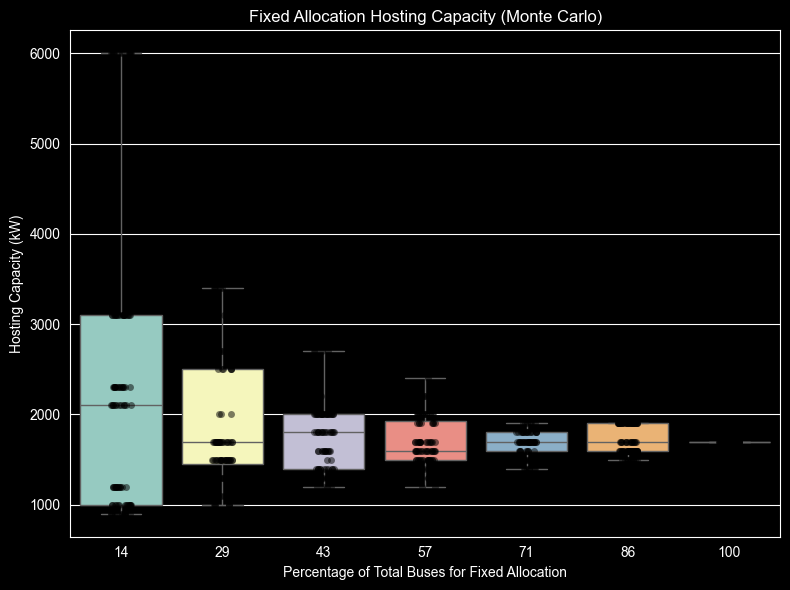

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
bus_pct = list(hc_total_dict.keys())
hc_lists = list(hc_total_dict.values())
sns.boxplot(data=hc_lists, showfliers=False, ax=ax)
sns.stripplot(data=hc_lists, jitter=True, color='black', alpha=0.5, ax=ax)
ax.set_xlabel('Percentage of Total Buses for Fixed Allocation')
ax.set_ylabel('Hosting Capacity (kW)')
ax.set_title('Fixed Allocation Hosting Capacity (Monte Carlo)')
ax.set_xticks(range(len(bus_pct)))
ax.set_xticklabels([int(p) for p in bus_pct])
plt.tight_layout()
plt.show()

## Additional learning resources

If you would like to continue learning OpenDSS and Python for power-system studies, you can find more educational materials and courses here:

- [pauloradatz.me](https://www.pauloradatz.me)
- [OpenDSS courses](https://www.pauloradatz.me/opendss-courses)

## Contact

For questions or follow-up about these materials:

- Paulo Radatz
- Email: [paulo.radatz@gmail.com](mailto:paulo.radatz@gmail.com)
- LinkedIn: [linkedin.com/in/pauloradatz](https://www.linkedin.com/in/pauloradatz/)
- Website: [pauloradatz.me](https://www.pauloradatz.me/)